# Logistic Regression for Phishing Detection

In [100]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


In [101]:
df = pd.read_csv("dataset1.csv")
df.columns = df.columns.str.strip()
df = df.drop('index', axis=1)
df.head()

,having_IPhaving_IP_Address,URLURL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## Simple Logistic Regression Model

In [102]:
X = df.drop(columns=["Result"])
y = df["Result"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

model = LogisticRegression(max_iter=10000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy

In [103]:
print("Simple Logistic Regression Results")
print("---------------------------")
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print()

print("Confusion Matrix:")
M = confusion_matrix(y_test, y_pred, labels=[-1, 1])
ConfusionMatrix = pd.DataFrame(M,index=['Legitimate (-1)', 'Phishing (1)'],columns=['Legitimate (-1)', 'Phishing (1)'])
ConfusionMatrix['total'] = ConfusionMatrix.sum(axis=1)
print(ConfusionMatrix)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred, labels=[-1, 1], target_names=["Legitimate (-1)", "Phishing (1)"]))

Simple Logistic Regression Results
---------------------------
Accuracy: 0.9289914066033469
Error Rate: 0.07100859339665311

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              884            96    980
Phishing (1)                  61          1170   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.94      0.90      0.92       980
   Phishing (1)       0.92      0.95      0.94      1231

       accuracy                           0.93      2211
      macro avg       0.93      0.93      0.93      2211
   weighted avg       0.93      0.93      0.93      2211



## Tuned Logistic Regression Evaluation

In [104]:
param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

logreg = LogisticRegression(max_iter=10000, random_state=42)

grid_search = GridSearchCV(logreg, param_grid, cv=5, scoring="accuracy", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters")
print("---------------")
print(grid_search.best_params_)
print()

print("Best Cross-Validation Accuracy")
print("------------------------------")
print(grid_search.best_score_)
print()

Best Parameters
---------------
{'C': 0.1}

Best Cross-Validation Accuracy
------------------------------
0.9275218762549591



In [105]:
best_logreg = grid_search.best_estimator_

y_pred_tuned = best_logreg.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
error_rate_tuned = 1 - accuracy_tuned

print("Tuned Logistic Regression Results")
print("---------------------------------")
print("Accuracy:", accuracy_tuned)
print("Error Rate:", error_rate_tuned)
print()

print("Confusion Matrix:")
M_tuned = confusion_matrix(y_test, y_pred_tuned, labels=[-1, 1])
ConfusionMatrix_tuned = pd.DataFrame(M_tuned, index=["Legitimate (-1)", "Phishing (1)"], columns=["Legitimate (-1)", "Phishing (1)"])
ConfusionMatrix_tuned["total"] = ConfusionMatrix_tuned.sum(axis=1)
print(ConfusionMatrix_tuned)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, labels=[-1, 1], target_names=["Legitimate (-1)", "Phishing (1)"]))

Tuned Logistic Regression Results
---------------------------------
Accuracy: 0.9326096788783356
Error Rate: 0.06739032112166443

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              887            93    980
Phishing (1)                  56          1175   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.94      0.91      0.92       980
   Phishing (1)       0.93      0.95      0.94      1231

       accuracy                           0.93      2211
      macro avg       0.93      0.93      0.93      2211
   weighted avg       0.93      0.93      0.93      2211



## Interpret Tuned Logistic Regression Coefficients
Logistic regression is interpretable because we can look at the coefficients.

Since 1 = phishing and -1 = legitimate:

Positive coefficients push the prediction toward phishing.

Negative coefficients push the prediction toward legitimate.


In [106]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": best_logreg.coef_[0],
    "Absolute Coefficient": np.abs(best_logreg.coef_[0])
})

feature_importance = feature_importance.sort_values(by="Absolute Coefficient", ascending=False)

print("Top 15 Most Important Features")
print("------------------------------")
print(feature_importance.head(15))
print()

print("Top Features Pushing Toward Phishing (1)")
print("----------------------------------------")
print(feature_importance.sort_values(by="Coefficient", ascending=False).head(10)[["Feature", "Coefficient"]])
print()

print("Top Features Pushing Toward Legitimate (-1)")
print("-------------------------------------------")
print(feature_importance.sort_values(by="Coefficient", ascending=True).head(10)[["Feature", "Coefficient"]])

Top 15 Most Important Features
------------------------------
                       Feature  Coefficient  Absolute Coefficient
13               URL_of_Anchor     2.795739              2.795739
5                Prefix_Suffix     1.729387              1.729387
7               SSLfinal_State     1.504943              1.504943
18                    Redirect    -0.891571              0.891571
15                         SFH     0.751037              0.751037
14               Links_in_tags     0.746965              0.746965
28      Links_pointing_to_page     0.723887              0.723887
25                 web_traffic     0.677426              0.677426
2           Shortining_Service    -0.578673              0.578673
27                Google_Index     0.577911              0.577911
6            having_Sub_Domain     0.552377              0.552377
0   having_IPhaving_IP_Address     0.529046              0.529046
24                   DNSRecord     0.424581              0.424581
10            

## Logistic Regression with Interaction Features

In [107]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_interactions = poly.fit_transform(X_train)
X_test_interactions = poly.transform(X_test)

interaction_feature_names = poly.get_feature_names_out(X.columns)

print("Original number of features:", X_train.shape[1])
print("Number of features after adding interaction terms:", X_train_interactions.shape[1])

Original number of features: 30
Number of features after adding interaction terms: 465


In [108]:
param_grid_interactions = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100]
}

logreg_interactions = LogisticRegression(max_iter=10000, random_state=42)

grid_search_interactions = GridSearchCV(
    estimator=logreg_interactions,
    param_grid=param_grid_interactions,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search_interactions.fit(X_train_interactions, y_train)

print("Best Parameters for Interaction Model")
print("-------------------------------------")
print(grid_search_interactions.best_params_)
print()

print("Best Cross-Validation Accuracy")
print("------------------------------")
print(grid_search_interactions.best_score_)
print()

Best Parameters for Interaction Model
-------------------------------------
{'C': 1}

Best Cross-Validation Accuracy
------------------------------
0.946178529680342



In [109]:
best_logreg_interactions = grid_search_interactions.best_estimator_

y_pred_interactions = best_logreg_interactions.predict(X_test_interactions)

accuracy_interactions = accuracy_score(y_test, y_pred_interactions)
error_rate_interactions = 1 - accuracy_interactions

print("Logistic Regression with Interaction Features Results")
print("-----------------------------------------------------")
print("Accuracy:", accuracy_interactions)
print("Error Rate:", error_rate_interactions)
print()

print("Confusion Matrix:")
M_interactions = confusion_matrix(y_test, y_pred_interactions, labels=[-1, 1])
ConfusionMatrix_interactions = pd.DataFrame(M_interactions, index=["Legitimate (-1)", "Phishing (1)"], columns=["Legitimate (-1)", "Phishing (1)"])
ConfusionMatrix_interactions["total"] = ConfusionMatrix_interactions.sum(axis=1)
print(ConfusionMatrix_interactions)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_interactions, labels=[-1, 1], target_names=["Legitimate (-1)", "Phishing (1)"]))

Logistic Regression with Interaction Features Results
-----------------------------------------------------
Accuracy: 0.9502487562189055
Error Rate: 0.04975124378109452

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              916            64    980
Phishing (1)                  46          1185   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.95      0.93      0.94       980
   Phishing (1)       0.95      0.96      0.96      1231

       accuracy                           0.95      2211
      macro avg       0.95      0.95      0.95      2211
   weighted avg       0.95      0.95      0.95      2211



## Interpret Interaction Model Coefficients

In [110]:
interaction_importance = pd.DataFrame({
    "Feature": interaction_feature_names,
    "Coefficient": best_logreg_interactions.coef_[0],
    "Absolute Coefficient": np.abs(best_logreg_interactions.coef_[0])
})

interaction_importance = interaction_importance.sort_values(by="Absolute Coefficient", ascending=False)

print("Top 15 Most Important Original/Interaction Features")
print("---------------------------------------------------")
print(interaction_importance.head(15))
print()

print("Top Features Pushing Toward Phishing (1)")
print("----------------------------------------")
print(interaction_importance.sort_values(by="Coefficient", ascending=False).head(10)[["Feature", "Coefficient"]])
print()

print("Top Features Pushing Toward Legitimate (-1)")
print("-------------------------------------------")
print(interaction_importance.sort_values(by="Coefficient", ascending=True).head(10)[["Feature", "Coefficient"]])

Top 15 Most Important Original/Interaction Features
---------------------------------------------------
                                        Feature  Coefficient  \
7                                SSLfinal_State     3.117636   
13                                URL_of_Anchor     2.541236   
5                                 Prefix_Suffix     2.204436   
53         having_IPhaving_IP_Address DNSRecord     1.966239   
166                Prefix_Suffix SSLfinal_State    -1.609698   
335                    URL_of_Anchor RightClick     1.528711   
343        URL_of_Anchor Links_pointing_to_page     1.512132   
385  Submitting_to_email Links_pointing_to_page     1.495665   
172                 Prefix_Suffix URL_of_Anchor    -1.451123   
174                           Prefix_Suffix SFH    -1.409225   
177                      Prefix_Suffix Redirect     1.333129   
213                      SSLfinal_State Favicon    -1.324856   
300                        HTTPS_token Redirect    -1.204537   


## PCA and Logistic Regression

In [111]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [112]:
pca_all = PCA()
pca_all.fit(X_train_scaled)

explained_variance = pca_all.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance ratio for each component:")
print(explained_variance)
print()

Explained variance ratio for each component:
[0.17975282 0.13551062 0.08710992 0.0531017  0.04765658 0.03948609
 0.03780424 0.0366748  0.03545865 0.03148819 0.03090675 0.02995132
 0.02916396 0.02698169 0.02657785 0.02243961 0.01979947 0.01911281
 0.01470289 0.01377775 0.0133026  0.01239137 0.01086273 0.01007907
 0.0093939  0.00793999 0.00727064 0.00525404 0.00431062 0.00173733]



<Axes: title={'center': 'PVE'}>

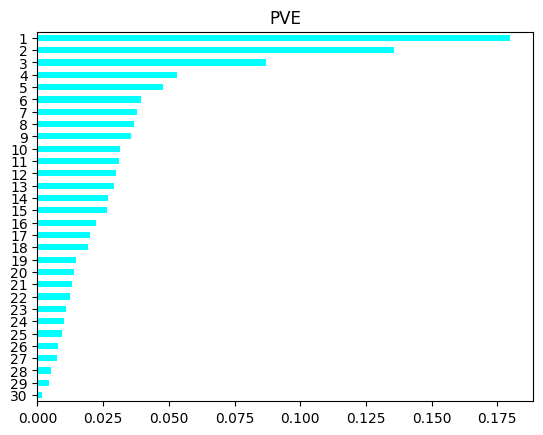

In [113]:
PVE = pca_all.explained_variance_ratio_
PVE = pd.Series(PVE,index=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])
PVE.sort_values().plot.barh(color='cyan',title='PVE')

In [114]:
pca_results = []

component_options = [3, 5, 9, 15, 18, 23, 27, 30]

for n in component_options:
    pca_temp = PCA(n_components=n)
    
    X_train_pca_temp = pca_temp.fit_transform(X_train_scaled)
    
    model_temp = LogisticRegression(max_iter=10000, random_state=42)
    
    scores = cross_val_score(
        model_temp,
        X_train_pca_temp,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    pca_results.append({
        "Number of Components": n,
        "Mean CV Accuracy": scores.mean(),
        "CV Std": scores.std()
    })

pca_results_df = pd.DataFrame(pca_results)

print("PCA Cross-Validation Results")
print("----------------------------")
print(pca_results_df)

PCA Cross-Validation Results
----------------------------
   Number of Components  Mean CV Accuracy    CV Std
0                     3          0.850521  0.006582
1                     5          0.912936  0.004806
2                     9          0.917233  0.005295
3                    15          0.922773  0.004711
4                    18          0.923791  0.004055
5                    23          0.926052  0.004214
6                    27          0.926165  0.004436
7                    30          0.926843  0.005020


In [115]:
best_num_components = 30
print("Best number of PCA components:", best_num_components)

pca_best = PCA(n_components=best_num_components)

X_train_pca_best = pca_best.fit_transform(X_train_scaled)
X_test_pca_best = pca_best.transform(X_test_scaled)

best_pca_logreg = LogisticRegression(max_iter=10000, random_state=42)
best_pca_logreg.fit(X_train_pca_best, y_train)

y_pred_pca_best = best_pca_logreg.predict(X_test_pca_best)

accuracy_pca_best = accuracy_score(y_test, y_pred_pca_best)
error_rate_pca_best = 1 - accuracy_pca_best

print("Tuned PCA + Logistic Regression Results")
print("---------------------------------------")
print("Accuracy:", accuracy_pca_best)
print("Error Rate:", error_rate_pca_best)
print()

print("Confusion Matrix:")
M_pca_best = confusion_matrix(y_test, y_pred_pca_best, labels=[-1, 1])
ConfusionMatrix_pca_best = pd.DataFrame(
    M_pca_best,
    index=["Legitimate (-1)", "Phishing (1)"],
    columns=["Legitimate (-1)", "Phishing (1)"]
)
ConfusionMatrix_pca_best["total"] = ConfusionMatrix_pca_best.sum(axis=1)
print(ConfusionMatrix_pca_best)
print()

print("Classification Report:")
print(classification_report(
    y_test,
    y_pred_pca_best,
    labels=[-1, 1],
    target_names=["Legitimate (-1)", "Phishing (1)"]
))

Best number of PCA components: 30
Tuned PCA + Logistic Regression Results
---------------------------------------
Accuracy: 0.9289914066033469
Error Rate: 0.07100859339665311

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              884            96    980
Phishing (1)                  61          1170   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.94      0.90      0.92       980
   Phishing (1)       0.92      0.95      0.94      1231

       accuracy                           0.93      2211
      macro avg       0.93      0.93      0.93      2211
   weighted avg       0.93      0.93      0.93      2211



## Feature Engineering + PCA + Logistic Regression

In [116]:
poly_fe_pca = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)

X_train_interactions_fe_pca = poly_fe_pca.fit_transform(X_train)
X_test_interactions_fe_pca = poly_fe_pca.transform(X_test)

interaction_feature_names_fe_pca = poly_fe_pca.get_feature_names_out(X.columns)

print("Original number of features:", X_train.shape[1])
print("Number of features after adding interaction terms:", X_train_interactions_fe_pca.shape[1])

Original number of features: 30
Number of features after adding interaction terms: 465


<Axes: title={'center': 'PVE for Feature Engineering + PCA'}>

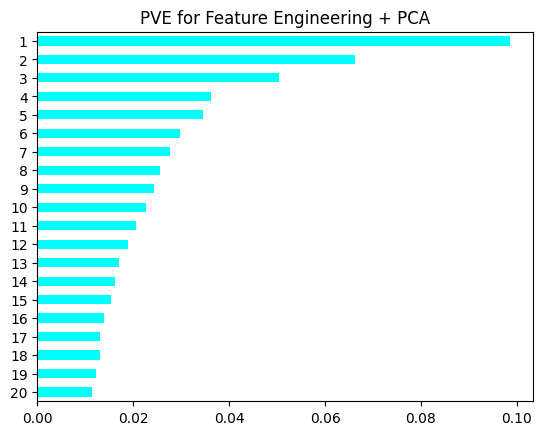

In [117]:
scaler_fe_pca = StandardScaler()

X_train_interactions_scaled_fe_pca = scaler_fe_pca.fit_transform(X_train_interactions_fe_pca)
X_test_interactions_scaled_fe_pca = scaler_fe_pca.transform(X_test_interactions_fe_pca)

pca_all_fe = PCA()
pca_all_fe.fit(X_train_interactions_scaled_fe_pca)

explained_variance_fe = pca_all_fe.explained_variance_ratio_
cumulative_variance_fe = np.cumsum(explained_variance_fe)

PVE_fe = pca_all_fe.explained_variance_ratio_
PVE_fe = pd.Series(PVE_fe, index=list(range(1, len(PVE_fe) + 1)))
PVE_fe.sort_values(ascending=False).head(20).sort_values().plot.barh(color='cyan', title='PVE for Feature Engineering + PCA')

In [118]:
pca_fe_results = []

component_options_fe = [5, 10, 20, 30, 50, 100, 200, X_train_interactions_fe_pca.shape[1]]

for n in component_options_fe:
    pca_temp_fe = PCA(n_components=n)
    
    X_train_pca_temp_fe = pca_temp_fe.fit_transform(X_train_interactions_scaled_fe_pca)
    
    model_temp_fe = LogisticRegression(max_iter=10000, random_state=42)
    
    scores_fe = cross_val_score(
        model_temp_fe,
        X_train_pca_temp_fe,
        y_train,
        cv=5,
        scoring="accuracy"
    )
    
    pca_fe_results.append({
        "Number of Components": n,
        "Mean CV Accuracy": scores_fe.mean(),
        "CV Std": scores_fe.std()
    })

pca_fe_results_df = pd.DataFrame(pca_fe_results)

print("Feature Engineering + PCA Cross-Validation Results")
print("--------------------------------------------------")
print(pca_fe_results_df)

Feature Engineering + PCA Cross-Validation Results
--------------------------------------------------
   Number of Components  Mean CV Accuracy    CV Std
0                     5          0.879694  0.008144
1                    10          0.895410  0.004489
2                    20          0.901178  0.007467
3                    30          0.917459  0.006014
4                    50          0.921190  0.008630
5                   100          0.925600  0.005104
6                   200          0.935098  0.008765
7                   465          0.946066  0.007450


In [119]:
best_num_components_fe = pca_fe_results_df.sort_values(by="Mean CV Accuracy", ascending=False).iloc[0]["Number of Components"]

best_num_components_fe = int(best_num_components_fe)

print("Best number of PCA components:", best_num_components_fe)

pca_best_fe = PCA(n_components=best_num_components_fe)

X_train_pca_best_fe = pca_best_fe.fit_transform(X_train_interactions_scaled_fe_pca)
X_test_pca_best_fe = pca_best_fe.transform(X_test_interactions_scaled_fe_pca)

best_fe_pca_logreg = LogisticRegression(max_iter=10000, random_state=42)
best_fe_pca_logreg.fit(X_train_pca_best_fe, y_train)

y_pred_fe_pca = best_fe_pca_logreg.predict(X_test_pca_best_fe)

accuracy_fe_pca = accuracy_score(y_test, y_pred_fe_pca)
error_rate_fe_pca = 1 - accuracy_fe_pca

print("Feature Engineering + PCA + Logistic Regression Results")
print("-------------------------------------------------------")
print("Accuracy:", accuracy_fe_pca)
print("Error Rate:", error_rate_fe_pca)
print()

print("Confusion Matrix:")
M_fe_pca = confusion_matrix(y_test, y_pred_fe_pca, labels=[-1, 1])

ConfusionMatrix_fe_pca = pd.DataFrame(M_fe_pca, index=["Legitimate (-1)", "Phishing (1)"], columns=["Legitimate (-1)", "Phishing (1)"])

ConfusionMatrix_fe_pca["total"] = ConfusionMatrix_fe_pca.sum(axis=1)

print(ConfusionMatrix_fe_pca)
print()

print("Classification Report:")
print(classification_report(y_test, y_pred_fe_pca, labels=[-1, 1], target_names=["Legitimate (-1)", "Phishing (1)"]))

Best number of PCA components: 465
Feature Engineering + PCA + Logistic Regression Results
-------------------------------------------------------
Accuracy: 0.9525101763907734
Error Rate: 0.0474898236092266

Confusion Matrix:
                 Legitimate (-1)  Phishing (1)  total
Legitimate (-1)              918            62    980
Phishing (1)                  43          1188   1231

Classification Report:
                 precision    recall  f1-score   support

Legitimate (-1)       0.96      0.94      0.95       980
   Phishing (1)       0.95      0.97      0.96      1231

       accuracy                           0.95      2211
      macro avg       0.95      0.95      0.95      2211
   weighted avg       0.95      0.95      0.95      2211

